In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [6]:
def cantor_intervals(n):
    """Return the list of closed intervals making up C_n."""
    intervals = [(0.0, 1.0)]
    for _ in range(n):
        next_intervals = []
        for a, b in intervals:
            third = (b - a) / 3
            next_intervals.append((a, a + third))
            next_intervals.append((b - third, b))
        intervals = next_intervals
    return intervals

def plot_cantor(n_iterations=7, bar_height=0.6, gap=1.0, color="#1f1f1f"):
    fig, ax = plt.subplots(figsize=(12, 0.6 * n_iterations + 1.5))

    for n in range(n_iterations + 1):
        y = (n_iterations - n) * gap 
        for a, b in cantor_intervals(n):
            ax.add_patch(Rectangle((a, y), b - a, bar_height, facecolor=color, edgecolor="none"))
        ax.text(-0.02, y + bar_height / 2, f"$C_{{{n}}}$",
                ha="right", va="center", fontsize=11)

    # Cosmetics
    ax.set_xlim(-0.06, 1.02)
    ax.set_ylim(-0.3, (n_iterations + 1) * gap)
    ax.set_xticks([0, 1/3, 2/3, 1])
    ax.set_xticklabels(["0", "1/3", "2/3", "1"])
    ax.set_yticks([])
    for spine in ("left", "right", "top"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="x", length=4)
    ax.set_title(
        f"$C_n$ — First {n_iterations} Iterations",
        fontsize=13, pad=12,
    )

    plt.tight_layout()
    return fig

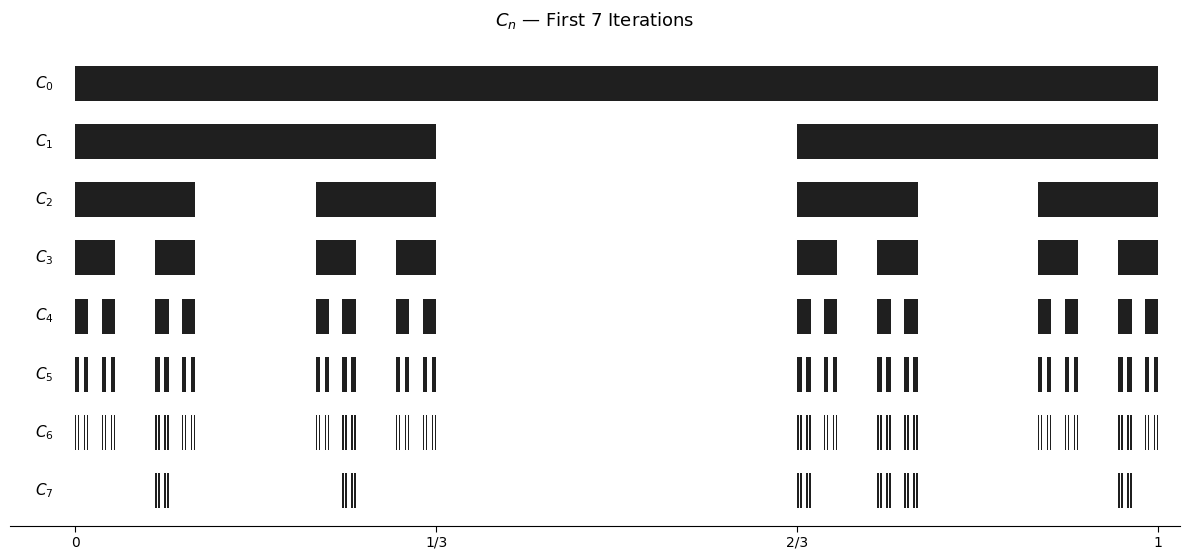

In [7]:
fig = plot_cantor(n_iterations=7)
fig.savefig("cantor_set.png", dpi=150, bbox_inches="tight")
plt.show()